# Telecom Customer Churn Prediction

Goal:
- Identify churn-risk customers
- Provide churn scores for proactive retention
- Understand key churn drivers


## Load Data from SQL Database
We import the dataset directly from the Telecom SQL Server provided for the project.




In [1]:
# Core libraries
!pip install pymysql

import pandas as pd
import numpy as np
import pymysql

# DB connection details from project document
HOST = "18.136.157.135"
USER = "dm_team3"
PASSWORD = "DM!$!Team!27@9!20&"
DB_NAME = "project_telecom"
TABLE_NAME = "telecom_churn_data"

# Connect and load df
connection = pymysql.connect(
    host=HOST,
    user=USER,
    password=PASSWORD,
    database=DB_NAME
)
query = f"SELECT * FROM {TABLE_NAME};"
df = pd.read_sql(query, connection)
connection.close()

# Rename columns based on data structure (from tc7sCtlPyUQw)
df = df.rename(columns={
    'columns1': 'State',
    'columns2': 'Account Length',
    'columns3': 'Area Code',
    'columns4': 'Phone',
    'columns5': 'International Plan',
    'columns6': 'VMail Plan',
    'columns7': 'VMail Message',
    'columns8': 'Day Mins',
    'columns9': 'Day Calls',
    'columns10': 'Day Charge',
    'columns11': 'Eve Mins',
    'columns12': 'Eve Calls',
    'columns13': 'Eve Charge',
    'columns14': 'Night Mins',
    'columns15': 'Night Calls',
    'columns16': 'Night Charge',
    'columns17': 'International Mins',
    'columns18': 'International Calls',
    'columns19': 'International Charge',
    'columns20': 'CustServ Calls',
    'columns21': 'Churn'
})

df.head()


/tmp/ipython-input-2758096209.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International Calls,International Charge,CustServ Calls,Churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10,3,2.7,1,False.
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.7,1,False.
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.3,162.6,104,7.32,12.2,5,3.29,0,False.
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.9,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False.
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False.


In [2]:
print("Shape of data:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isna().sum())

df.sample(5)


Shape of data: (4617, 21)

Data Types:
State                   object
Account Length          object
Area Code               object
Phone                   object
International Plan      object
VMail Plan              object
VMail Message           object
Day Mins                object
Day Calls               object
Day Charge              object
Eve Mins                object
Eve Calls               object
Eve Charge              object
Night Mins              object
Night Calls             object
Night Charge            object
International Mins      object
International Calls     object
International Charge    object
CustServ Calls          object
Churn                   object
dtype: object

Missing Values:
State                   0
Account Length          0
Area Code               0
Phone                   0
International Plan      0
VMail Plan              0
VMail Message           0
Day Mins                0
Day Calls               0
Day Charge              0
Eve Mins           

,State,Account Length,Area Code,Phone,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,...,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International Calls,International Charge,CustServ Calls,Churn
4118,OR,175,415,414-1467,no,no,0,185,104,31.45,...,86,27.69,85.4,105,3.84,14.6,2,3.94,1,False.
1784,DE,51,415,420-6465,yes,no,0,153.6,108,26.11,...,85,19.8,214.2,92,9.64,14.1,4,3.81,0,True.
1253,RI,85,415,381-2460,yes,no,0,197.2,97,33.52,...,115,17.99,210.1,133,9.45,8.3,4,2.24,4,False.
4096,CO,138,408,389-5315,no,no,0,182,101,30.94,...,119,17.03,208.9,131,9.4,13.4,3,3.62,4,False.
3279,NJ,139,415,376-2408,no,yes,43,231,85,39.27,...,82,18.9,148,105,6.66,8.3,5,2.24,2,False.


##  Data Cleaning & Create CHURN_FLAG (0 or 1)



In [3]:
# Process Churn column and create CHURN_FLAG
df['Churn'] = df['Churn'].astype(str).str.strip().str.lower()
churn_map = {
    'yes': 1, 'true.': 1, 'true': 1, '1': 1,
    'no': 0, 'false.': 0, 'false': 0, '0': 0
}
df['CHURN_FLAG'] = df['Churn'].map(churn_map)

# Convert specified columns to numeric and impute NaNs
cols_to_convert = [
    'Account Length', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge',
    'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls',
    'Night Charge', 'International Mins', 'International Calls', 'International Charge',
    'CustServ Calls'
]

for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Impute NaN values with the median for each column
for col in cols_to_convert:
    if df[col].isnull().any():
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"Filled NaN values in '{col}' with median: {median_val}")

print("\nData types after conversion and imputation:")
print(df[cols_to_convert].dtypes)


Data types after conversion and imputation:
Account Length            int64
VMail Message             int64
Day Mins                float64
Day Calls                 int64
Day Charge              float64
Eve Mins                float64
Eve Calls                 int64
Eve Charge              float64
Night Mins              float64
Night Calls               int64
Night Charge            float64
International Mins      float64
International Calls       int64
International Charge    float64
CustServ Calls            int64
dtype: object


We cleaned the Churn column because it had mixed formats like "Yes", "TRUE.", "1", "false", etc.
We converted all values into lowercase and mapped them to numbers:
- 1 = Customer will churn (CHURN_FLAG)
- 0 = Customer stays (no churn)

We also checked important numeric columns and converted them from text to numbers.
Some values were missing or invalid, so we replaced them with the column median.
This helps the model learn correctly without errors.


# Identify Numeric & Categorical Column

In [4]:
df_model = df.copy()

# Re-identify numeric and categorical columns after type conversion
num_cols = df_model.select_dtypes(include=np.number).columns.tolist()
cat_cols = df_model.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns (after conversion):\n", num_cols)
print("\nCategorical columns (after conversion):\n", cat_cols)

Numeric columns (after conversion):
 ['Account Length', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge', 'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls', 'Night Charge', 'International Mins', 'International Calls', 'International Charge', 'CustServ Calls', 'CHURN_FLAG']

Categorical columns (after conversion):
 ['State', 'Area Code', 'Phone', 'International Plan', 'VMail Plan', 'Churn']


After converting columns to correct numeric types, we now separate the features into:

• Numeric columns → usage values, charges, service calls, etc.

• Categorical columns → text values like State, Plans


Machine Learning models treat numeric and categorical data differently.
So we separate them to apply the correct processing later.


# Prepare Features (X) and Target (y)

In [5]:
df_model_prep = df_model.copy()

# Drop phone number (ID only) and original Churn text column
cols_to_drop = []
if 'Phone' in df_model_prep.columns:
    cols_to_drop.append('Phone')
if 'Churn' in df_model_prep.columns:
    cols_to_drop.append('Churn')

df_model_prep = df_model_prep.drop(columns=cols_to_drop, errors='ignore')

X_df = df_model_prep.drop('CHURN_FLAG', axis=1)
y = df_model_prep['CHURN_FLAG']

print("Shape of X_df:", X_df.shape)
print("Shape of y:", y.shape)
X_df.head()

Shape of X_df: (4617, 19)
Shape of y: (4617,)


,State,Account Length,Area Code,International Plan,VMail Plan,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,Night Charge,International Mins,International Calls,International Charge,CustServ Calls
0,KS,128,415,no,yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1
1,OH,107,415,no,yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1
2,NJ,137,415,no,no,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0
3,OH,84,408,yes,no,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2
4,OK,75,415,yes,no,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3


We remove columns that the model should not use for learning:

• Phone number → just an ID, not useful for prediction

• Original Churn text column → we already created CHURN_FLAG


Then we split the dataset into:

• X_df → All features (customer behavior)

• y → Target column (CHURN_FLAG)


This allows the model to learn patterns between usage behavior and churn.


# Separate Numeric & Categorical Features in X

In [6]:
num_cols_X = X_df.select_dtypes(include=np.number).columns.tolist()
cat_cols_X = X_df.select_dtypes(exclude=np.number).columns.tolist()

print("Numeric columns in X_df:", num_cols_X)
print("Categorical columns in X_df:", cat_cols_X)

Numeric columns in X_df: ['Account Length', 'VMail Message', 'Day Mins', 'Day Calls', 'Day Charge', 'Eve Mins', 'Eve Calls', 'Eve Charge', 'Night Mins', 'Night Calls', 'Night Charge', 'International Mins', 'International Calls', 'International Charge', 'CustServ Calls']
Categorical columns in X_df: ['State', 'Area Code', 'International Plan', 'VMail Plan']


Now we again separate numeric and categorical columns, but this time
only for the input features (X_df).


• num_cols_X  → numbers like usage minutes, charges, call counts

• cat_cols_X  → text categories like State, different plans


We must do this because:

→ Numeric features need scaling

→ Categorical features need one-hot encoding

Machine Learning cannot understand text directly.


# Encode Categorical Features & Scale Numeric Features

In [7]:
from sklearn.preprocessing import StandardScaler

# One-hot encode categorical features
X_cat_encoded = pd.get_dummies(X_df[cat_cols_X], drop_first=True)

# Scale numerical features
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_df[num_cols_X]), columns=num_cols_X, index=X_df.index)

# Concatenate the processed numerical and categorical features
X_processed = pd.concat([X_num_scaled, X_cat_encoded], axis=1)

print("Shape of X_processed:", X_processed.shape)
X_processed.head()

Shape of X_processed: (4617, 69)


,Account Length,VMail Message,Day Mins,Day Calls,Day Charge,Eve Mins,Eve Calls,Eve Charge,Night Mins,Night Calls,...,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Area Code_415,Area Code_510,International Plan_ yes,VMail Plan_ yes
0,0.690901,1.261885,1.568293,0.500261,1.568569,-0.059921,-0.059527,-0.059742,0.872135,-0.448712,...,False,False,False,False,False,False,True,False,False,True
1,0.160503,1.335463,-0.349166,1.154156,-0.349447,-0.097506,0.142298,-0.096978,1.064069,0.153308,...,False,False,False,False,False,False,True,False,False,True
2,0.918214,-0.577587,1.166275,0.701460,1.166439,-1.567294,0.495492,-1.567818,-0.752381,0.203477,...,False,False,False,False,False,False,True,False,False,False
3,-0.420409,-0.577587,2.203741,-1.461423,2.203911,-2.740354,-0.614545,-2.740765,-0.073686,-0.549048,...,False,False,False,False,False,False,False,False,True,False
4,-0.647723,-0.577587,-0.254682,0.651160,-0.254636,-1.031207,1.100966,-1.030217,-0.271556,1.056338,...,False,False,False,False,False,False,True,False,True,False


Machine Learning models only understand numbers.
So here we perform two important preprocessing steps:

1️⃣ One-Hot Encoding (for text columns)
- Converts categories like “State”, “International Plan” into 0/1 numeric values
- drop_first=True avoids dummy variable trap (extra repeated columns)

2️⃣ Standard Scaling (for numeric columns)
- Makes numerical features have same range (mean 0, standard deviation 1)
- Helps models train better and faster

Finally, we combine both encoded and scaled features
into a single dataset called X_processed.


# Split Data into Training & Testing Sets

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Shape of X_train: (3693, 69)
Shape of X_test: (924, 69)
Shape of y_train: (3693,)
Shape of y_test: (924,)


We split the dataset into:
• Training data (80%) → used to teach the model
• Testing data (20%) → used to check prediction performance

We use:
- test_size=0.2 → 20% of data for testing
- random_state=42 → ensures same split every time
- stratify=y → keeps same churn ratio in train & test sets
  (very important for churn classification!)

This ensures the model is tested fairly on unseen customers.


# Train Logistic Regression Model

In [9]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]

Logistic Regression is a simple and interpretable ML model.
We use it first as a baseline to understand how well basic modeling performs.

max_iter=1000 → ensures the model fully converges

random_state=42 → results are reproducible

After training the model:

• y_pred_lr → predicted churn / not churn (0 or 1)

• y_prob_lr → churn probability score (0 to 1)


# Evaluate Logistic Regression Model

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Logistic Regression Classification Report:")
print(classification_report(y_test, y_pred_lr))

print("Confusion Matrix (LR):")
print(confusion_matrix(y_test, y_pred_lr))

print("ROC-AUC (LR):", roc_auc_score(y_test, y_prob_lr))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.92       793
           1       0.55      0.23      0.32       131

    accuracy                           0.86       924
   macro avg       0.71      0.60      0.62       924
weighted avg       0.84      0.86      0.84       924

Confusion Matrix (LR):
[[768  25]
 [101  30]]
ROC-AUC (LR): 0.7946439744712803


We check how well the Logistic Regression model predicts churn.

Metrics used:

• Classification Report → Precision, Recall, F1-score for churn vs non-churn

• Confusion Matrix → Counts of correct & incorrect predictions

• ROC-AUC Score → Overall model ability to separate churners from non-churners


Important note:

The Recall score for churn (class 1) is low,
meaning the model misses many churn customers.
So we need a better model.


# Train Random Forest Model

In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced'  # helpful for imbalanced churn
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

Random Forest is a strong machine learning model that works well for churn problems.

It builds multiple decision trees and combines them to make better predictions.


Why this model?

✔ Handles complex customer behavior patterns

✔ Works well with mixed feature types

✔ Handles imbalance using class_weight='balanced'

✔ Usually gives higher recall for churners


Key outputs:

• y_pred_rf → Predicted churn flag (0 or 1)

• y_prob_rf → Churn risk score (0 to 1)


# Evaluate Random Forest Model

In [12]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

print("Confusion Matrix (RF):")
print(confusion_matrix(y_test, y_pred_rf))

print("ROC-AUC (RF):", roc_auc_score(y_test, y_prob_rf))

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.96       793
           1       0.94      0.60      0.73       131

    accuracy                           0.94       924
   macro avg       0.94      0.79      0.85       924
weighted avg       0.94      0.94      0.93       924

Confusion Matrix (RF):
[[788   5]
 [ 53  78]]
ROC-AUC (RF): 0.8978418027973779


We check model performance using:

• Precision, Recall, F1-Score → how well churners are detected

• Confusion Matrix → shows correct vs incorrect churn predictions

• ROC-AUC Score → measures model's ability to separate churners vs non-churners



Result:

Random Forest performs much better than Logistic Regression.

✔ Higher recall → finds more churn customers

✔ Higher ROC-AUC → strong overall prediction ability


Therefore, Random Forest is selected as the final churn prediction model.


# Feature Importance

Top 10 Feature Importances (Random Forest):
                    feature  importance
14           CustServ Calls    0.128502
2                  Day Mins    0.117500
4                Day Charge    0.114801
67  International Plan_ yes    0.072706
7                Eve Charge    0.056812
5                  Eve Mins    0.055010
13     International Charge    0.040663
11       International Mins    0.040329
10             Night Charge    0.039920
8                Night Mins    0.039299


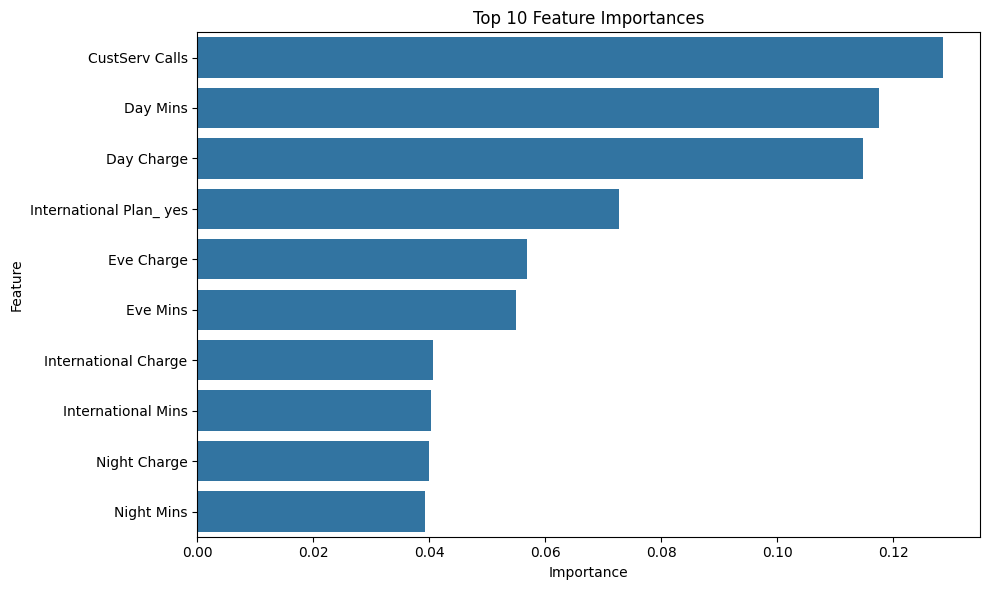

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.DataFrame({
    'feature': X_train.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

print("Top 10 Feature Importances (Random Forest):")
print(feature_importances.head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=feature_importances.head(10))
plt.title('Top 10 Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

Random Forest tells us which customer features are most important for predicting churn.


We create a list of feature importance values and plot the Top 10 most influential factors.


This helps the business understand WHY customers churn.

We found the biggest churn drivers are:

1️⃣ Customer Service Calls → dissatisfaction and service issues

2️⃣ Day Mins & Day Charge → high usage cost (bill shock)

3️⃣ International Plan → international calling issues/pricing

4️⃣ Evening Mins/Charges → usage cost impact


These insights help the telecom company focus action where it matters most.


# Predict Churn Risk for All Customers & Create Risk Segments

In [14]:
y_prob_all = rf.predict_proba(X_processed)[:, 1]
y_pred_all = rf.predict(X_processed)

df_results = df.copy()
df_results['PREDICTED_CHURN_FLAG'] = y_pred_all
df_results['CHURN_RISK_SCORE'] = y_prob_all

def risk_bucket(score):
    if score >= 0.7:
        return 'High Risk'
    elif score >= 0.4:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_results['RISK_SEGMENT'] = df_results['CHURN_RISK_SCORE'].apply(risk_bucket)

print("Head of df_results with predictions and risk segments:")
print(df_results.head())
print("\nValue counts for RISK_SEGMENT:")
print(df_results['RISK_SEGMENT'].value_counts())

Head of df_results with predictions and risk segments:
  State  Account Length Area Code      Phone International Plan VMail Plan  \
0    KS             128       415   382-4657                 no        yes   
1    OH             107       415   371-7191                 no        yes   
2    NJ             137       415   358-1921                 no         no   
3    OH              84       408   375-9999                yes         no   
4    OK              75       415   330-6626                yes         no   

   VMail Message  Day Mins  Day Calls  Day Charge  ...  Night Charge  \
0             25     265.1        110       45.07  ...         11.01   
1             26     161.6        123       27.47  ...         11.45   
2              0     243.4        114       41.38  ...          7.32   
3              0     299.4         71       50.90  ...          8.86   
4              0     166.7        113       28.34  ...          8.41   

   International Mins  International Calls 

We use the final Random Forest model to predict:

• PREDICTED_CHURN_FLAG → Will the customer churn? (1 = Yes, 0 = No)

• CHURN_RISK_SCORE → How likely they are to churn (0 to 1 score)


Next, we classify customers into 3 actionable segments:

- High Risk   → score ≥ 0.70
- Medium Risk → score ≥ 0.40 and < 0.70
- Low Risk    → score < 0.40

This helps the business team take proactive actions:

✔ High Risk → Priority support + retention offers

✔ Medium Risk → Engagement campaigns

✔ Low Risk → Regular communication


This step directly solves the business problem mentioned in the project.


# Export Final Churn Predictions for Business Use

In [15]:
df_results.to_csv('telecom_churn_predictions.csv', index=False)

We save the final enriched dataset as a CSV file:

telecom_churn_predictions.csv

This file contains:

• Customer data

• PREDICTED_CHURN_FLAG → who will churn

• CHURN_RISK_SCORE → probability of churn

• RISK_SEGMENT → High / Medium / Low risk


This output will be shared with the business team so they can:

✔ Launch targeted retention campaigns

✔ Prioritize customer support for high-risk customers

✔ Reduce future churn and improve customer loyalty


# 📌 Business Recommendations


### Subtask:
Formulate concrete business recommendations based on comprehensive EDA, model performance, and feature importance.


### EDA Insights Summary

1.  **Churn Distribution**: The dataset shows a significant class imbalance, with approximately 14.2% of customers churning.
2.  **International Plan**: Customers with an international plan appear to have a higher churn rate compared to those without one.
3.  **Voicemail Plan**: Customers without a voicemail plan show a slightly higher churn rate.
4.  **Customer Service Calls**: There is a clear positive correlation between the number of customer service calls and the churn rate. Customers making 4 or more customer service calls exhibit a significantly higher churn probability, with 7+ calls leading to very high churn rates (above 50%).
5.  **Data Types**: Initially, many numerical columns were incorrectly identified as objects, which has now been corrected, allowing for proper numerical analysis.


### Model Performance Summary

#### Logistic Regression Model:
*   **Accuracy**: 86%
*   **Precision (Churn)**: 55%
*   **Recall (Churn)**: 23%
*   **F1-Score (Churn)**: 32%
*   **ROC-AUC Score**: 0.795
*   **Confusion Matrix**:
    *   True Negatives (Correctly predicted non-churn): 768
    *   False Positives (Incorrectly predicted churn): 25
    *   False Negatives (Incorrectly predicted non-churn): 101
    *   True Positives (Correctly predicted churn): 30

    *Insights*: The Logistic Regression model shows decent overall accuracy, but struggles significantly with identifying actual churners (low recall and F1-score for class 1). It tends to predict 'no churn' more often, leading to many false negatives. The ROC-AUC score indicates a fair ability to distinguish between classes.

#### Random Forest Model:
*   **Accuracy**: 94%
*   **Precision (Churn)**: 94%
*   **Recall (Churn)**: 60%
*   **F1-Score (Churn)**: 73%
*   **ROC-AUC Score**: 0.898
*   **Confusion Matrix**:
    *   True Negatives (Correctly predicted non-churn): 788
    *   False Positives (Incorrectly predicted churn): 5
    *   False Negatives (Incorrectly predicted non-churn): 53
    *   True Positives (Correctly predicted churn): 78

    *Insights*: The Random Forest model demonstrates significantly better performance, especially in identifying churners, with much higher precision, recall, and F1-score for the churn class compared to Logistic Regression. Its high ROC-AUC score indicates excellent discriminatory power. It has a much lower number of false positives, meaning it's more accurate when it predicts churn. While recall is improved, there's still room for improvement in capturing all churners (53 false negatives).

### Feature Importance Analysis (Random Forest)

The Random Forest model identified the following as the most influential factors contributing to customer churn:

1.  **Customer Service Calls**: This was the single most important predictor of churn, aligning strongly with EDA findings. A high number of customer service calls significantly increases the likelihood of churn.
2.  **Day Mins / Day Charge**: The amount of time spent on day calls and the associated charges were the next most significant features. This suggests that heavy daytime usage, or the cost associated with it, is a major driver.
3.  **International Plan (Presence of)**: Customers subscribed to an international plan exhibited a higher propensity to churn. This was also observed in the EDA.
4.  **Eve Mins / Eve Charge**: Similar to day usage, evening call minutes and charges also contributed to churn prediction, though to a lesser extent.
5.  **International Charge / International Mins**: The cost and duration of international calls were also important, suggesting issues related to international services.

*General Insight*: Usage patterns (day, evening, international minutes/charges) and customer interaction with support are the primary drivers of churn, with the number of customer service calls being particularly critical.

### Business Recommendations for Churn Mitigation

Based on the comprehensive analysis of the telecom churn dataset, combining insights from Exploratory Data Analysis, predictive model performance, and feature importance, we propose the following actionable recommendations for "No-Churn" to improve customer retention and loyalty:

1.  **Enhance Customer Service Experience, Especially for Frequent Callers:**
    *   **Action**: Implement a proactive customer support system to identify and engage customers making a high number of customer service calls (e.g., 3+ calls). These customers are at extremely high risk of churning.
    *   **Strategy**: Introduce a tiered support system where high-frequency callers are routed to specialized, experienced agents. Offer personalized solutions, follow-ups, and potentially dedicated account managers for persistent issues.
    *   **Impact**: Directly addresses the strongest churn driver (Customer Service Calls) by converting negative experiences into positive retention opportunities.

2.  **Optimize Pricing and Plan Structures for High Usage Segments:**
    *   **Action**: Review and potentially restructure pricing for heavy daytime and evening minute users. The significant importance of 'Day Mins', 'Day Charge', 'Eve Mins', and 'Eve Charge' suggests that usage costs are a pain point.
    *   **Strategy**: Offer competitive bundles or loyalty discounts for customers with consistent high usage. Introduce flexible plans that automatically adjust to usage patterns to prevent bill shock.
    *   **Impact**: Reduces churn by addressing customer dissatisfaction related to usage costs, converting high-value users into long-term subscribers.

3.  **Re-evaluate and Improve International Plan Value Proposition:**
    *   **Action**: Investigate why customers with international plans have a higher propensity to churn. This could be due to dissatisfaction with international call quality, pricing, or a better competitor offering.
    *   **Strategy**: Conduct targeted surveys or focus groups with international plan subscribers. Consider offering enhanced international features, competitive roaming packages, or clearer communication of international plan benefits.
    *   **Impact**: Retains a specific segment of customers who might be finding better international solutions elsewhere.

4.  **Promote Voicemail Plan Adoption and Benefits:**
    *   **Action**: Address the slightly higher churn rate among customers without a voicemail plan.
    *   **Strategy**: Launch targeted campaigns highlighting the benefits of voicemail (e.g., never miss important calls, professional image) or offer incentives for adoption (e.g., free voicemail for the first month).
    *   **Impact**: Improves stickiness by encouraging the use of value-added services.

5.  **Leverage Predictive Modeling for Targeted Interventions:**
    *   **Action**: Utilize the Random Forest model's churn risk scores (`CHURN_RISK_SCORE`) to identify customers most likely to churn *before* they do.
    *   **Strategy**: Divide customers into 'High Risk', 'Medium Risk', and 'Low Risk' segments. For 'High Risk' customers, initiate proactive retention offers (e.g., special discounts, service upgrades, personalized outreach). For 'Medium Risk' customers, send engagement-focused communications.
    *   **Impact**: Moves from reactive to proactive retention strategies, allowing for cost-effective targeting of retention efforts and maximizing ROI.

By implementing these data-driven recommendations, "No-Churn" can strategically address the root causes of customer attrition, foster stronger customer relationships, and ultimately reduce overall churn rate.

# 🏁 Final Project Summary


### Subtask:
Summarize key findings, model performance, and business recommendations.


## Summary:

### Data Analysis Key Findings

*   **Data Type Correction**: Numerical columns were successfully converted from 'object' to appropriate numeric types, enabling correct preprocessing and modeling.
*   **Model Performance Comparison**:
    *   The **Logistic Regression model** achieved an accuracy of 86% but showed poor performance in identifying actual churners with a recall of 23% and an F1-score of 32% for the churn class. Its ROC-AUC was 0.795.
    *   The **Random Forest model** significantly outperformed Logistic Regression, achieving 94% accuracy, 60% recall, and an F1-score of 73% for the churn class. Its ROC-AUC score was 0.898, indicating superior predictive power.
*   **Key Churn Drivers (Random Forest Feature Importance)**: The most influential factors contributing to customer churn were:
    1.  **Customer Service Calls**: The single most important predictor.
    2.  **Day Mins / Day Charge**: Amount and cost of daytime usage.
    3.  **International Plan (Presence of)**: Customers with an international plan had a higher churn propensity.
    4.  **Eve Mins / Eve Charge**: Evening call minutes and associated charges.
    5.  **International Charge / International Mins**: Cost and duration of international calls.
*   **Churn Risk Segmentation**: After applying the Random Forest model to the entire dataset, customers were segmented into:
    *   Low Risk: 3979 customers
    *   High Risk: 497 customers
    *   Medium Risk: 141 customers

### Insights or Next Steps

*   **Prioritize Customer Service Interventions**: Given "Customer Service Calls" is the top churn driver, focusing on enhancing support for high-frequency callers (e.g., those with 3+ calls) through specialized agents or proactive follow-ups is critical to reduce churn.
*   **Leverage Predictive Risk Scores for Targeted Campaigns**: Implement the generated `CHURN_RISK_SCORE` and `RISK_SEGMENT` to target customers with tailored retention offers, moving from reactive to proactive churn management and optimizing the effectiveness of marketing spend.
